In [1]:
import lfox
import lfox.lattice as lat
import lfox.evolution.hmc as lhmc
import jax
import jax.numpy as jnp
import numpy as np

# Imports below require "dev" environment
import matplotlib.pyplot as plt
import lsqfit
import gvar as gv
import tqdm

# Double precision!
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_threefry_partitionable", True)


In [2]:
class ScalarAction(lhmc.Action):        

    @staticmethod
    @jax.jit
    def _S(fields, params):
        phi = fields[0]
        S = phi**2
        
        for ax in range(phi.d()):
            S -= 2 * params['kappa'] * phi * phi.nn_field(ax)

        S += params['lambda'] * (phi**2 - 1)**2
        return S
    
    # Exact force function instead of autodiff, for testing purposes
    @staticmethod
    @jax.jit
    def exact_force(fields, params):
        phi = fields[0]

        J = phi.nn_field(axis=0, shift=1) + phi.nn_field(axis=0, shift=-1)
        for ax in range(1,phi.d):
            J += phi.nn_field(axis=ax, shift=1)
            J += phi.nn_field(axis=ax, shift=-1)

        F = -2 * params['kappa'] * J
        F += 2 * phi.F
        F += 4 * params['lambda'] * (phi.F**2 - 1) * phi.F

        return F

In [3]:
%%time

# First test case: exercise 2.5
d = 3
Lat4 = lat.SquareLattice(st_dims=((4,)*d))
phi4 = lat.LatticeField(lattice=Lat4, F=1)

#LA = jax.live_arrays()
#print(len(LA)) # 3651866

S4 = ScalarAction(field_names=['phi'], params={'kappa': 0.18169, 'lambda': 1.3282})

all_Nstep = np.array([10, 20, 30, 40, 50])
all_eps = 1/all_Nstep

all_dH_leap = []
all_dH_om = []

for eps, Nstep in zip(all_eps, all_Nstep):
    HMC_leap = lhmc.HMCEvolver(
        action=S4,
        seed=72345,
        init_fields={'phi': phi4},
        integrator=lhmc.LeapfrogIntegrator(eps=eps, Nstep=Nstep),
    )
    HMC_om = lhmc.HMCEvolver(
        action=S4,
        seed=87735,
        init_fields={'phi': phi4},
        integrator=lhmc.OmelyanIntegrator(eps=eps, Nstep=Nstep),
    )

    HMC_leap.evolve(ntraj=50, warmup=True)
    HMC_om.evolve(ntraj=50, warmup=True)

    abs_dH_leap = np.abs(np.array(HMC_leap.monitor['delta_H']))
    abs_dH_om = np.abs(np.array(HMC_om.monitor['delta_H']))

    all_dH_leap.append(gv.dataset.avg_data(abs_dH_leap))
    all_dH_om.append(gv.dataset.avg_data(abs_dH_om))


I0000 00:00:1708119440.372376       1 tfrt_cpu_pjrt_client.cc:349] TfrtCpuClient created.


CPU times: user 5.68 s, sys: 409 ms, total: 6.09 s
Wall time: 5.43 s


In [4]:
%%time

# First test case: exercise 2.5
d = 3
Lat4 = lat.SquareLattice(st_dims=((4,)*d))
phi4 = lat.LatticeField(lattice=Lat4, F=1)

#LA = jax.live_arrays()
#print(len(LA)) # 3651866

S4 = ScalarAction(field_names=['phi'], params={'kappa': 0.18169, 'lambda': 1.3282})

all_Nstep = np.array([10, 20, 30, 40, 50])
all_eps = 1/all_Nstep

all_dH_leap = []
all_dH_om = []

rng_key = jax.random.PRNGKey(4819)

for eps, Nstep in zip(all_eps, all_Nstep):
    HMC_leap = lhmc.HMCRewrite(
        action=S4,
        integrator=lhmc.LeapfrogIntegrator(eps=eps, Nstep=Nstep),
    )
    HMC_om = lhmc.HMCRewrite(
        action=S4,
        integrator=lhmc.OmelyanIntegrator(eps=eps, Nstep=Nstep),
    )

    F4 = {'phi': phi4}
    monitor_leap = {}
    monitor_om = {}
    
    for _ in range(50):
        F4, mleap, rng_key = HMC_leap.evolve(F4, rng_key, warmup=True)
        F4, mom, rng_key = HMC_om.evolve(F4, rng_key, warmup=True)
        
        for key in mleap.keys():
            if monitor_leap.get(key) is None:
                monitor_leap[key] = []
            if monitor_om.get(key) is None:
                monitor_om[key] = []
            monitor_leap[key].append(mleap[key])
            monitor_om[key].append(mom[key])

    abs_dH_leap = np.abs(np.array(monitor_leap['delta_H']))
    abs_dH_om = np.abs(np.array(monitor_om['delta_H']))

    all_dH_leap.append(gv.dataset.avg_data(abs_dH_leap))
    all_dH_om.append(gv.dataset.avg_data(abs_dH_om))

CPU times: user 965 ms, sys: 50.3 ms, total: 1.02 s
Wall time: 949 ms


Least Square Fit:
  chi2/dof [dof] = 0.32 [5]    Q = 0.9    logGBF = 6.6048

Parameters:
              a   -0.00051 (83)      [    0 (100) ]  
              b      15.8 (1.2)      [    0 (500) ]  

Settings:
  svdcut/n = 1e-12/0    tol = (1e-08*,1e-10,1e-10)    (itns/time = 3/0.0)
  fitter = scipy_least_squares    method = trf

Least Square Fit:
  chi2/dof [dof] = 0.59 [5]    Q = 0.71    logGBF = 12.401

Parameters:
              a   0.000039 (91)      [    0 (100) ]  
              b       1.66 (13)      [    0 (500) ]  

Settings:
  svdcut/n = 1e-12/0    tol = (1e-08*,1e-10,1e-10)    (itns/time = 3/0.0)
  fitter = scipy_least_squares    method = trf



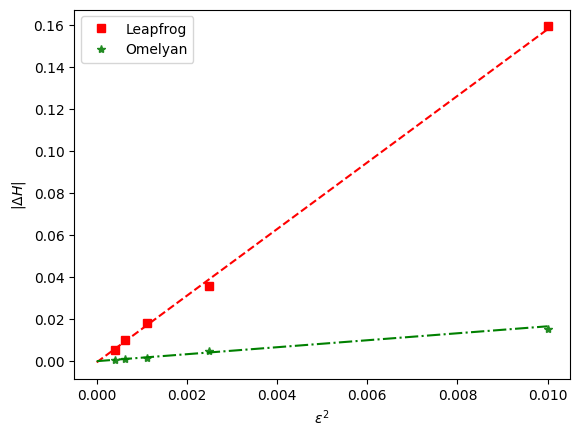

In [5]:
#Figure 2.2
plt.plot(all_eps**2, gv.mean(all_dH_leap), ls=' ', marker='s', color='red', label='Leapfrog')
plt.plot(all_eps**2, gv.mean(all_dH_om), ls=' ', marker='*', color='forestgreen', label='Omelyan')

def lin(x,p):
    return p['a'] + p['b']*x

fit_leap = lsqfit.nonlinear_fit(data=(all_eps**2, all_dH_leap), prior={'a': gv.gvar(0,100), 'b': gv.gvar(0,500)}, fcn=lin)
print(fit_leap)

eps_ls = np.linspace(0,0.1,100)
plt.plot(eps_ls**2, gv.mean(lin(eps_ls**2,fit_leap.p)), ls='--', color='red')

fit_om = lsqfit.nonlinear_fit(data=(all_eps**2, all_dH_om), prior={'a': gv.gvar(0,100), 'b': gv.gvar(0,500)}, fcn=lin)
print(fit_om)

plt.plot(eps_ls**2, gv.mean(lin(eps_ls**2,fit_om.p)), ls='-.', color='green')

plt.xlabel('$\epsilon^2$')
plt.ylabel('$|\Delta H|$')
plt.legend()

Another technical plot first: let's do figure 2.4.

In [6]:
LA = jax.live_arrays()
print(len(LA)) # 3651866

933


In [7]:
%%time

# First test case: exercise 2.5
d = 3
Lat6 = lat.SquareLattice(st_dims=((6,)*d))
phi6 = lat.LatticeField(lattice=Lat6, F=1)
#phi6.field = np.ones_like(phi6.field)

S6 = ScalarAction(field_names=['phi'], params={'kappa': 0.185825, 'lambda': 1.1689})

all_Nstep = np.array([4, 5, 7, 8, 10, 20, 30, 40, 50])
all_eps = 1/all_Nstep

all_acc_rate = []
rng_key = jax.random.PRNGKey(11134)

for eps, Nstep in zip(all_eps, all_Nstep):
    F6 = {'phi': phi6}
    HMC = lhmc.HMCRewrite(
        action=S6,
        integrator=lhmc.LeapfrogIntegrator(eps=eps, Nstep=Nstep),
    )

    acc_rate = []
    for _ in range(1000):
        F6, mon, rng_key = HMC.evolve(F6, rng_key, warmup=False)
        acc_rate.append(mon['accept'])

    all_acc_rate.append(np.mean(np.array(acc_rate)))
    

CPU times: user 1.42 s, sys: 37.8 ms, total: 1.45 s
Wall time: 1.05 s


In [8]:
LA = jax.live_arrays()
print(len(LA)) # 3651866

2944


Text(0, 0.5, 'acc rate')

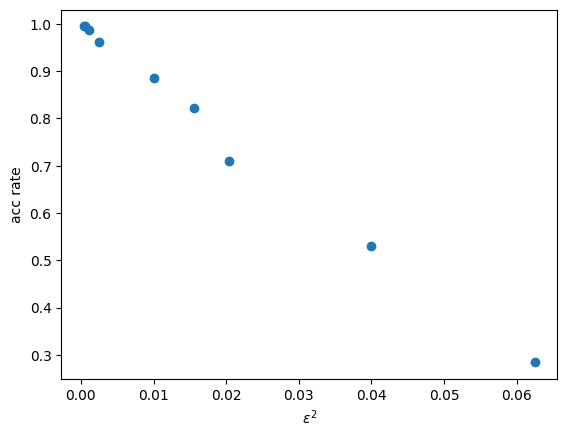

In [9]:
plt.plot(all_eps**2, all_acc_rate, ls=' ', marker='o')

plt.xlabel('$\epsilon^2$')
plt.ylabel('acc rate')

Text(0, 0.5, '$1/\\epsilon/$ acc rate [cost]')

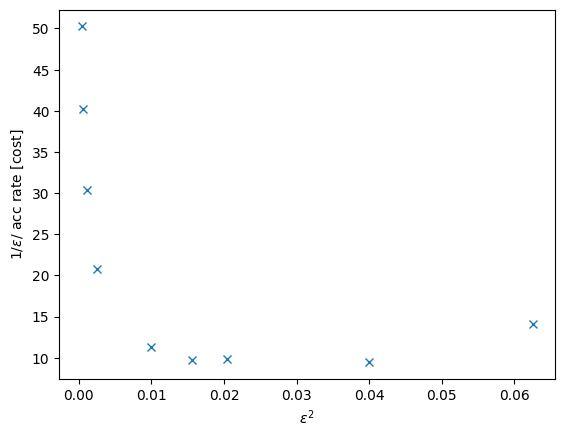

In [10]:
plt.plot(all_eps**2, 1/all_eps/all_acc_rate, ls=' ', marker='x')
plt.xlabel('$\epsilon^2$')
plt.ylabel('$1/\epsilon/$ acc rate [cost]')

Some additional technical tests.  Let's verify that $e^{-\Delta H}$ averages to 1 properly.

In [11]:
%%time
HMC = lhmc.HMCRewrite(
    action=ScalarAction(field_names=['phi'], params={'kappa': 0.18, 'lambda': 1.145}),
    integrator=lhmc.LeapfrogIntegrator(eps=0.1, Nstep=10),
)

Ftest = {'phi': phi6}
rng_key = jax.random.PRNGKey(21245)
dH_array = []
for _ in range(10000):
    Ftest, mon, rng_key = HMC.evolve(Ftest, rng_key, warmup=False)
    dH_array.append(mon['delta_H'])

CPU times: user 1.32 s, sys: 27.3 ms, total: 1.35 s
Wall time: 897 ms


1.011(23)

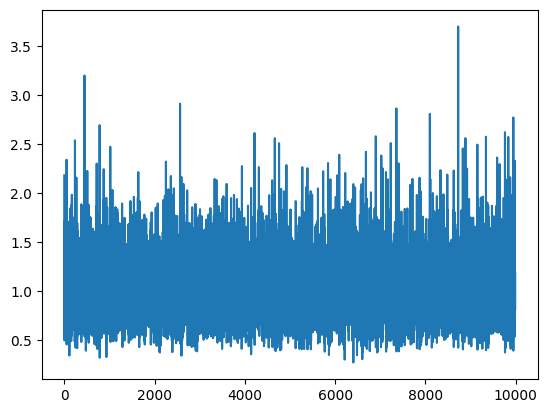

In [12]:
edH = np.exp(-np.array(dH_array))
plt.plot(edH[10:])
gv.dataset.avg_data(edH[100::50])  # Block by 50, should be consistent with 1

Now on to figure 2.3 and comparing HMC to MD.

In [6]:
@jax.jit
def mag(phi):
    m = jnp.sum(phi.F)
    return jnp.array([m, m**2, m**4])

def mag_obs(fields, params):
    return mag(fields['phi'])

In [12]:
%%prun -s cumulative

# Second test case: figure 2.3
d = 3
Lat6 = lat.SquareLattice(st_dims=((6,)*d))
phi6 = lat.LatticeField(lattice=Lat6, F=1)

#S6_HMC = ScalarAction({'phi': phi6}, params={'kappa': 0.185825, 'lamb': 1.1689})
#S6_HMD = ScalarAction({'phi': phi6}, params={'kappa': 0.185825, 'lamb': 1.1689})

all_Nstep = np.array([4,5,6,7,8,10])
#all_Nstep = np.array([4])
# Try tau = 2
all_eps = 1/all_Nstep
m2_HMC = []
m2_HMD = []

raw_HMC = []
mon_HMC = []

rng_key = jax.random.PRNGKey(73645)
F6_HMC = {'phi': phi6}
F6_HMD = {'phi': phi6}

for eps, Nstep in zip(all_eps, all_Nstep):
    print(eps, Nstep)

    raw_m2_HMC = []
    raw_m2_HMD = []
    
    HMC = lhmc.HMCRewrite(
        action=ScalarAction(field_names=['phi'], params={'kappa': 0.185825, 'lambda': 1.1689}),
#        integrator=lhmc.OmelyanIntegrator(eps=eps, Nstep=Nstep),
        integrator=lhmc.LeapfrogIntegrator(eps=eps, Nstep=Nstep),
    )
    
#    HMD = lhmc.HMCEvolver(
#        action=ScalarAction(field_names=['phi'], params={'kappa': 0.185825, 'lambda': 1.1689}),
#        integrator=lhmc.LeapfrogIntegrator(eps=eps, Nstep=Nstep),
#    )
    
    for t in range(1000):
        #F6_HMC, _, rng_key = HMC.evolve(F6_HMC, rng_key, warmup=False)
        #F6_HMD, _, rng_key = HMC.evolve(F6_HMD, rng_key, warmup=True)
        F6_HMC, _, rng_key = HMC.evolve_many(F6_HMC, rng_key, traj=100, warmup=False)
        F6_HMD, _, rng_key = HMC.evolve_many(F6_HMD, rng_key, traj=100, warmup=True)

        raw_m2_HMC.append(mag(F6_HMC['phi'])[1]/6**d)
        raw_m2_HMD.append(mag(F6_HMD['phi'])[1]/6**d)
    
    m2_HMC.append(gv.dataset.avg_data(raw_m2_HMC))
    m2_HMD.append(gv.dataset.avg_data(raw_m2_HMD))



0.25 4
0.2 5
0.16666666666666666 6
0.14285714285714285 7
0.125 8
0.1 10
 

         5909521 function calls (5909508 primitive calls) in 46.083 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.001    0.001   46.122   46.122 {built-in method builtins.exec}
        1   44.108   44.108   46.121   46.121 <string>:1(<module>)
    12000    0.020    0.000    1.453    0.000 array.py:297(__getitem__)
    12000    0.007    0.000    1.411    0.000 lax_numpy.py:4267(_rewriting_take)
    12000    0.124    0.000    1.404    0.000 lax_numpy.py:4195(_attempt_rewriting_take_via_slice)
    24012    0.018    0.000    1.033    0.000 core.py:383(bind)
    24012    0.018    0.000    0.924    0.000 core.py:388(bind_with_trace)
    24012    0.014    0.000    0.853    0.000 core.py:820(process_primitive)
    24010    0.056    0.000    0.799    0.000 dispatch.py:113(apply_primitive)
    12000    0.008    0.000    0.651    0.000 slicing.py:54(slice)
    12000    0.033    0.000    0.540    0.000 slicing.py:115

In [13]:
LA = jax.live_arrays()
print(len(LA)) # 3651866

3650865


In [25]:
%%prun -s cumulative

S_old = HMC.action.S_field(HMC.fields)

for _ in range(500):
    HMC.MD_traj(HMC.fields, HMC.pi_fields)      # 3.4 sec
#    HMC._MD_traj_2(HMC.fields, HMC.pi_fields)  # 2.9 sec
#    HMC.action.S_field(HMC.fields)  # 0.02 sec
#    HMC._H_density(list(HMC.pi_fields.values()), S_old)  # 0.06 sec
#    HMC.integrator.integrate(                  # 2.78 sec
#        delta_X = HMC.delta_X,
#        delta_P = HMC.delta_P,
#        X = HMC.fields,
#        P = HMC.pi_fields,
#    )

         123039 function calls in 3.072 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    3.072    3.072 {built-in method builtins.exec}
        1    0.039    0.039    3.072    3.072 <string>:1(<module>)
      500    0.124    0.000    3.032    0.006 hmc.py:435(MD_traj)
      500    0.142    0.000    2.908    0.006 hmc.py:465(_MD_traj_2)
      500    0.000    0.000    2.723    0.005 _module.py:873(__call__)
      500    2.716    0.005    2.722    0.005 hmc.py:301(integrate)
      500    0.001    0.000    0.029    0.000 _module.py:534(__get__)
      500    0.003    0.000    0.020    0.000 _module.py:443(__call__)
     1501    0.006    0.000    0.010    0.000 _module.py:687(_flatten_module)
     3001    0.002    0.000    0.009    0.000 lattice.py:164(_tree_unflatten)
      500    0.002    0.000    0.009    0.000 _module.py:935(_module_update_wrapper)
      500    0.001    0.000    0.008    0.000 

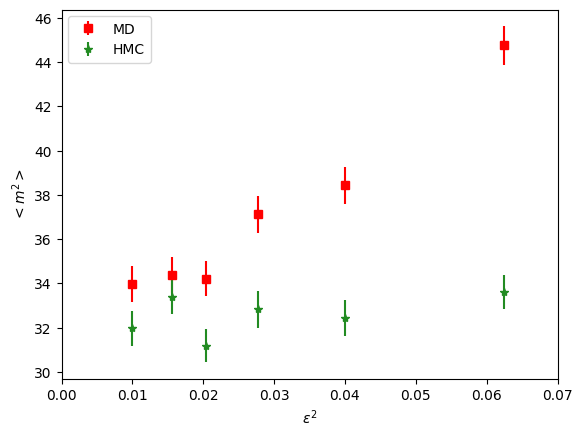

In [13]:
plt.errorbar(all_eps**2, gv.mean(m2_HMD), gv.sdev(m2_HMD), ls=' ', marker='s', color='red', label='MD')
plt.errorbar(all_eps**2, gv.mean(m2_HMC), gv.sdev(m2_HMC), ls=' ', marker='*', color='forestgreen', label='HMC')

plt.xlim(0,0.07)
plt.xlabel('$\epsilon^2$')
plt.ylabel('$<m^2>$')
plt.legend()

Finally the big physics result, figure 2.5!

In [ ]:
from tqdm import tqdm

d = 3

all_kappa = np.array([0.05, 0.10, 0.15, 0.16, 0.17, 0.175, 0.18, 0.185, 0.19, 0.195, 0.2, 0.21, 0.22])
all_L = (6,8,10)

mag_k = {}
rng_key = jax.random.PRNGKey(58105)

for L in tqdm(all_L):
    mag_k[L] = []

    Lat = lat.SquareLattice(st_dims=((L,)*d))
    phi_L = lat.LatticeField(lattice=Lat, F=1)

    for k in all_kappa:
        raw_mag = []
        fields = {'phi': phi_L}
        Sk = ScalarAction(field_names=['phi'], params={'kappa': k, 'lambda': 1.1689})
    
        HMC = lhmc.HMCRewrite(
            action=Sk,
            integrator=lhmc.OmelyanIntegrator(eps=0.1, Nstep=10),
        )

        fields, _, rng_key = HMC.evolve_many(fields, rng_key, traj=100, warmup=True)
    
        for _ in range(200):
            fields, _, rng_key = HMC.evolve_many(fields, rng_key, traj=100)
            raw_mag.append(mag(fields['phi'])[0])
    
        raw_m = np.abs(np.array(raw_mag))/L**d
    
        mag_k[L].append(gv.dataset.avg_data(raw_m))
    

 67%|████████████████████████████████████████████████████████████████████████████████████████████████████████████                                                      | 2/3 [01:08<00:35, 35.48s/it]

(0.15, 0.22)

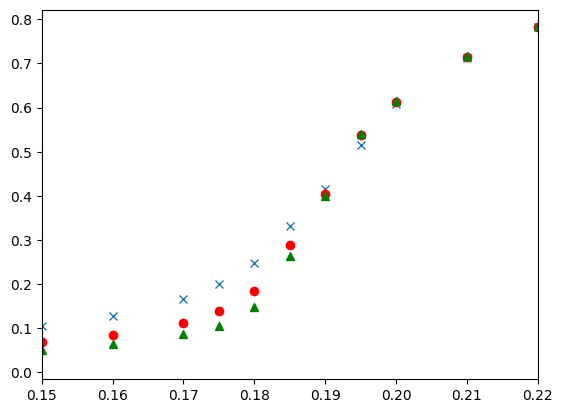

In [18]:
plt.plot(all_kappa, gv.mean(mag_k[6]), ls=' ', marker='x')
plt.plot(all_kappa, gv.mean(mag_k[8]), ls=' ', marker='o', color='red')
plt.plot(all_kappa, gv.mean(mag_k[10]), ls=' ', marker='^', color='green')

plt.xlim(0.15, 0.22)

Autocorrelation analysis...

In [21]:
d = 3
Lat6 = lat.SquareLattice(dims=((6,)*d))
phi6 = lat.LatticeField(Lat6)

HMC = lhmc.HMCEvolver(
    action=ScalarAction(field_names=['phi'], params={'kappa': 0.185825, 'lambda': 1.1689}),
    seed=21245,
    init_fields={'phi': phi6},
    integrator=lhmc.OmelyanIntegrator(eps=0.1, Nstep=10),
    observables={'mag': (mag_obs, 1)},
)

HMC.evolve(ntraj=1000, warmup=True)

for _ in tqdm(range(1000)):
    HMC.evolve(ntraj=1000)

100%|██████████████████████████████████████████████████████████| 1000/1000 [03:00<00:00,  5.55it/s]


In [22]:
dH = np.array(HMC.monitor['delta_H'])
gv.dataset.avg_data(np.exp(-dH))

1.000003(36)

0.0096(39)

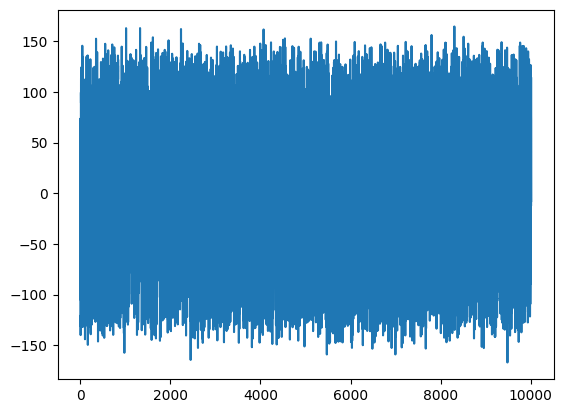

In [23]:
m = np.array(HMC.obs_chain['mag'])[:,0]
plt.plot(m[::100])

gv.dataset.avg_data(m[::100]/6**3)

In [24]:
mu, Ns = np.mean(m), len(m)
print(mu, Ns)

def Gamma(t):
    C1 = m - mu
    C2 = np.roll(m, t) - mu
    return gv.dataset.avg_data(C1[:Ns-t] * C2[:Ns-t] / (Ns - t))

2.301753935610712 1001000


<ErrorbarContainer object of 3 artists>

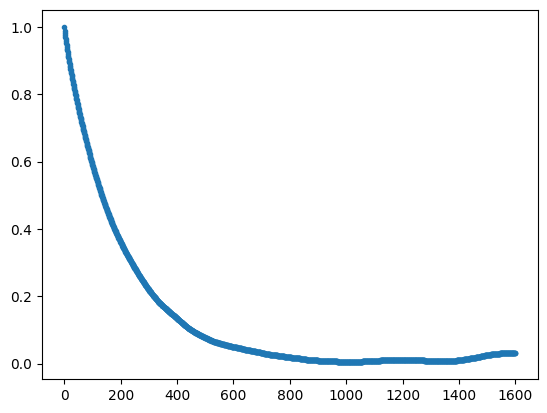

In [25]:
gam = [ Gamma(t)/Gamma(0) for t in range(0,1600) ]
plt.errorbar(range(0,1600), gv.mean(gam), gv.sdev(gam), ls=' ', marker='.')

<ErrorbarContainer object of 3 artists>

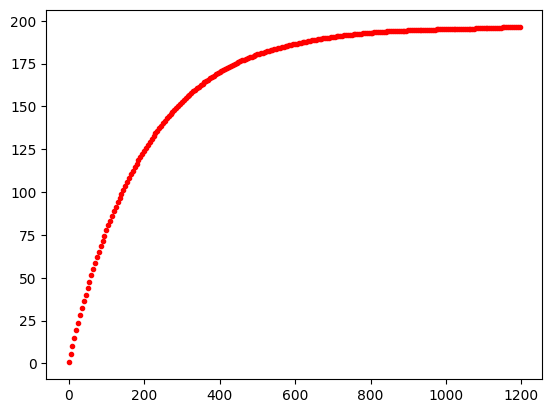

In [26]:
def tau(W):
    return 0.5 + np.sum(gam[:W])

taus = [ tau(W) for W in range(0,1200,5) ]
plt.errorbar(range(0,1200,5), gv.mean(taus), gv.sdev(taus), ls=' ', marker='.', color='red')